In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from mlxtend.frequent_patterns import apriori
from mlxtend.frequent_patterns import association_rules

df=pd.read_csv("online_retail.csv")

In [2]:
df.head() #first five rows

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [3]:
df.tail() #last five rows

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680.0,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France
541908,581587,22138,BAKING SET 9 PIECE RETROSPOT,3,2011-12-09 12:50:00,4.95,12680.0,France


In [4]:
df.shape

(541909, 8)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


In [6]:
df.columns

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country'],
      dtype='object')

In [7]:
df.describe()

,Quantity,UnitPrice,CustomerID
count,541909.000000,541909.000000,406829.000000
mean,9.552250,4.611114,15287.690570
std,218.081158,96.759853,1713.600303
min,-80995.000000,-11062.060000,12346.000000
25%,1.000000,1.250000,13953.000000
50%,3.000000,2.080000,15152.000000
75%,10.000000,4.130000,16791.000000
max,80995.000000,38970.000000,18287.000000


In [8]:
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [9]:
df=df.dropna()
df=df.drop_duplicates()

In [10]:
df = df[~df['InvoiceNo'].astype(str).str.startswith('C')]

In [11]:
df = df[df['Quantity'] > 0] #filter only positive counts 
df.to_csv("cleaned_data.csv", index=False)

In [13]:
df['InvoiceNo'].nunique()

18536

In [14]:
df['Description'].nunique()

3877

In [17]:
top_products = df['Description'].value_counts().head(10)

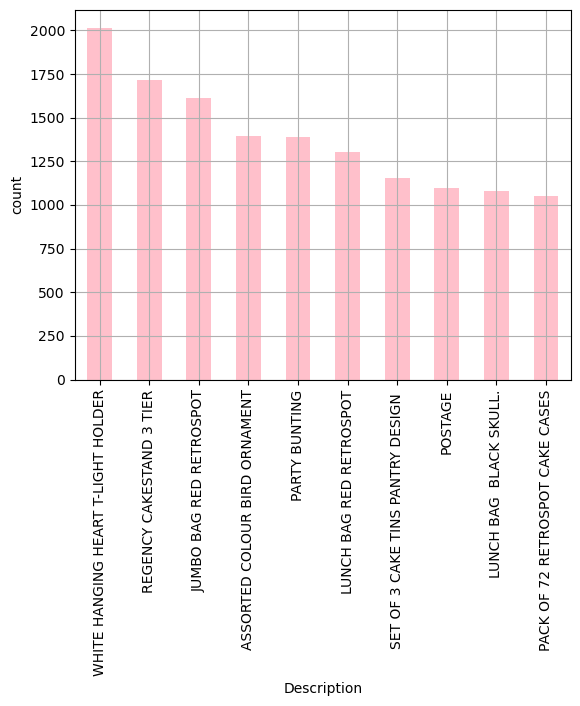

In [18]:
top_products.plot(kind='bar',color="pink")
plt.ylabel("count")
plt.grid(True)
plt.savefig("product_frequency.png")
plt.show()

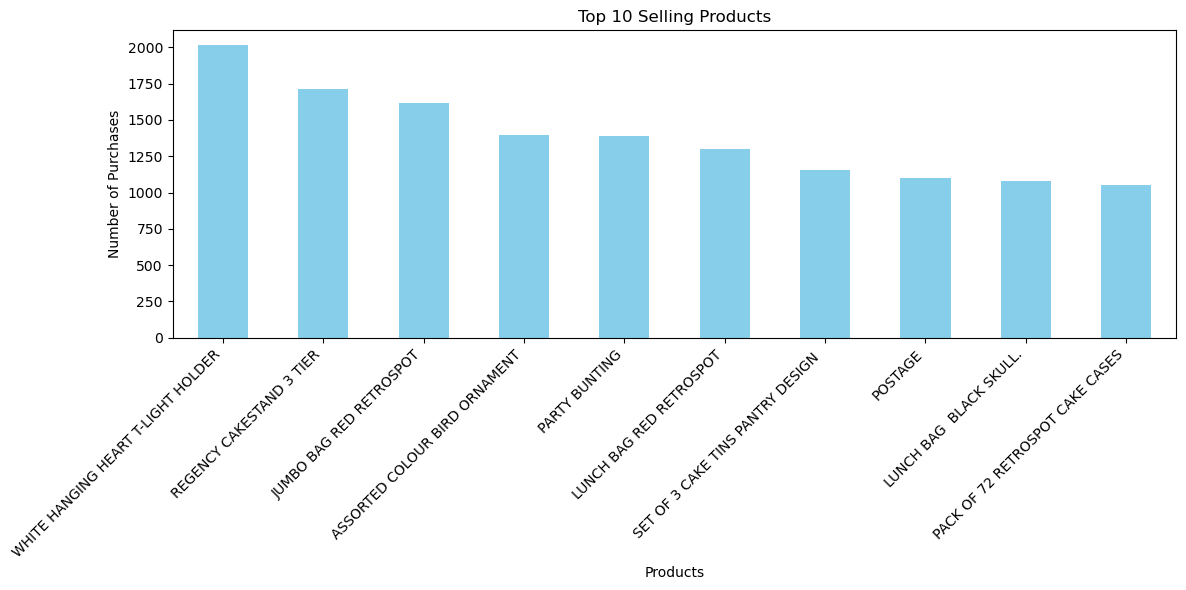

In [27]:
# Top 10 selling products
top_products = df['Description'].value_counts().head(10)
plt.figure(figsize=(12,6))
top_products.plot(kind='bar', color="skyblue")

plt.title("Top 10 Selling Products")
plt.xlabel("Products")
plt.ylabel("Number of Purchases")
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.savefig("top_products.png", dpi=300)

plt.show()

In [19]:
basket = df.groupby(['InvoiceNo','Description'])['Quantity'].sum().unstack().fillna(0)

In [20]:
basket = (basket>0)

In [21]:
frequent_itemsets = apriori(
    basket,
    min_support=0.02,
    use_colnames=True
)

In [22]:
rules = association_rules(
    frequent_itemsets,
    metric="lift",
    min_threshold=1
)

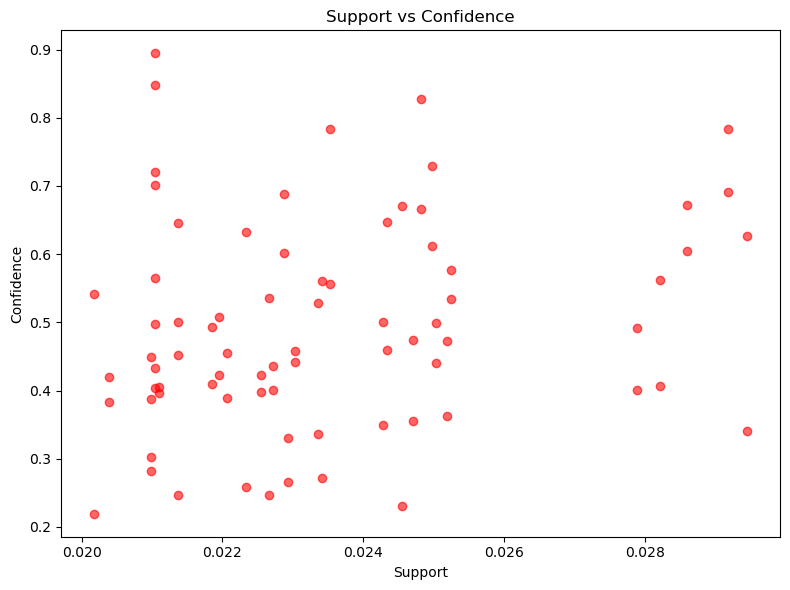

In [30]:
plt.figure(figsize=(8,6))
plt.scatter(
    rules['support'],
    rules['confidence'],
    alpha=0.6,
    color="red"
)
plt.xlabel("Support")
plt.ylabel("Confidence")
plt.title("Support vs Confidence")
plt.tight_layout()
plt.savefig("support_confidence_plot.png", dpi=300)

plt.show()

In [23]:
rules.sort_values(
    by='lift',
    ascending=False
)
rules[
    (rules['lift'] > 2) &
    (rules['confidence'] > 0.5)
]

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
0,(ALARM CLOCK BAKELIKE RED ),(ALARM CLOCK BAKELIKE GREEN),0.047313,0.042566,0.028593,0.604333,14.197612,1.0,0.026579,2.419798,0.975731,0.466549,0.586742,0.638035
1,(ALARM CLOCK BAKELIKE GREEN),(ALARM CLOCK BAKELIKE RED ),0.042566,0.047313,0.028593,0.671736,14.197612,1.0,0.026579,2.902200,0.970892,0.466549,0.655434,0.638035
3,(ALARM CLOCK BAKELIKE PINK),(ALARM CLOCK BAKELIKE RED ),0.033071,0.047313,0.021364,0.646003,13.653725,1.0,0.019799,2.691230,0.958457,0.361974,0.628423,0.548771
4,(DOLLY GIRL LUNCH BOX),(SPACEBOY LUNCH BOX ),0.033233,0.037980,0.022874,0.688312,18.122934,1.0,0.021612,3.086480,0.977300,0.473214,0.676006,0.645292
5,(SPACEBOY LUNCH BOX ),(DOLLY GIRL LUNCH BOX),0.037980,0.033233,0.022874,0.602273,18.122934,1.0,0.021612,2.430729,0.982122,0.473214,0.588601,0.645292
6,(GARDENERS KNEELING PAD KEEP CALM ),(GARDENERS KNEELING PAD CUP OF TEA ),0.040785,0.034258,0.024978,0.612434,17.877282,1.0,0.023581,2.491813,0.984204,0.498922,0.598686,0.670784
7,(GARDENERS KNEELING PAD CUP OF TEA ),(GARDENERS KNEELING PAD KEEP CALM ),0.034258,0.040785,0.024978,0.729134,17.877282,1.0,0.023581,3.541286,0.977552,0.498922,0.717617,0.670784
8,(PINK REGENCY TEACUP AND SAUCER),(GREEN REGENCY TEACUP AND SAUCER),0.029996,0.037279,0.024817,0.827338,22.193256,1.0,0.023698,5.575760,0.984471,0.584498,0.820652,0.746520
9,(GREEN REGENCY TEACUP AND SAUCER),(PINK REGENCY TEACUP AND SAUCER),0.037279,0.029996,0.024817,0.665702,22.193256,1.0,0.023698,2.901615,0.991919,0.584498,0.655364,0.746520
10,(GREEN REGENCY TEACUP AND SAUCER),(REGENCY CAKESTAND 3 TIER),0.037279,0.091929,0.020177,0.541245,5.887623,1.0,0.016750,1.979422,0.862298,0.185057,0.494802,0.380364


In [24]:
frequent_itemsets.to_csv("frequent_itemsets.csv", index=False)

rules.to_csv("association_rules.csv", index=False)